# Train a detector on answers you have already judged

You start with the whole training set already in hand: answers the model under test
generated, and a verdict on each. This notebook turns that pair into a fitted detector.

A detector is trained for one model — it scores how uncertain *that* model was while it
generated — so the responses must come from the model you want to detect hallucinations
in, carrying their `top_logprobs`. The wider context is in the guide's *Training a
detector*.

It walks that training set through the package end to end: reading the two batch files,
running the three pipeline steps by hand, fitting, cross-validating, and saving the result.

The sample files are synthetic: real questions, with the responses and their
log-probabilities generated rather than sampled from a model.


In [1]:
# From a clone: `uv sync --group notebooks`.
#
# On Colab, uncomment to install the package and fetch the files this notebook reads.
# !pip install -q artefactual matplotlib
# !wget -q https://raw.githubusercontent.com/artefactory/artefactual/main/docs/examples/responses_sample.jsonl
# !wget -q https://raw.githubusercontent.com/artefactory/artefactual/main/docs/examples/judgments_sample.jsonl

## The inputs

`RESPONSES` holds what the model under test generated, one OpenAI Batch line per request,
each carrying `top_logprobs` per token — that distribution is the only thing the detector
reads. `JUDGMENTS` holds a verdict on each of those responses, keyed by the same
`custom_id`, from an LLM judge, a human pass, or matching against a gold answer.

`read_batch` reads the lines, `read_judgment` reads the verdict inside one. A failed
request carries no completion and `failure` says why: two of the hundred lines are timeouts,
leaving 98 responses. `read_judgment` returns `True` when the judge said the response was
**correct**, the opposite of the class the detector predicts, so the label is its
negation.


In [2]:
from pathlib import Path

from artefactual.preprocessing import index_by_custom_id, read_batch, read_judgment, read_message

# Responses generated by the model this detector is being built for, one OpenAI Batch line
# each, carrying `top_logprobs` per token. This is the file to swap for your own run.
RESPONSES = Path("responses_sample.jsonl")
# A verdict on each of those responses, keyed by the same `custom_id`.
JUDGMENTS = Path("judgments_sample.jsonl")
K = 15  # ranks per token; a detector is loaded at the k it was fit at
SEED = 42

# `read_batch` validates each line into `BatchRequestOutput` and refuses a repeated
# `custom_id`, which would otherwise pair a response with another question's verdict.
lines = read_batch(RESPONSES)
for row in lines:
    if row.failure:
        print(f"dropped {row.custom_id}: {row.failure}")

generated = index_by_custom_id(lines)
# `read_judgment` returns True when the judge said the response was CORRECT, the opposite
# of the class the detector predicts.
labelled = [
    (generated[row.custom_id], int(not verdict))
    for row in read_batch(JUDGMENTS)
    if row.custom_id in generated and (verdict := read_judgment(row.completion)) is not None
]

responses = [row for row, _ in labelled]
labels = [label for _, label in labelled]
print(f"{len(generated)} responses, {len(labelled)} judged, {sum(labels)} hallucinations")

dropped q-017: error {'message': 'simulated upstream timeout'}
dropped q-062: error {'message': 'simulated upstream timeout'}
98 responses, 98 judged, 47 hallucinations


## The three steps

A detector is a scikit-learn `Pipeline`, and running its steps separately shows what each
one contributes.

`LogProbParser` turns the batch lines into `(responses, tokens, ranks)` — it opens the Batch
envelope itself, so the lines go in as they were read. The array is NaN-padded, because
responses differ in length: here the longest is 4 tokens, and every token carries all 15
ranks.

`entropy_contributions` converts each log-probability to `s_kj = -p·ln(p)`, same shape, one
contribution per rank. `EntropyTransformer` then reduces the rank axis: the `wepr` reduction
keeps a mean and a max per rank, so `k=15` becomes **30** features per response, one
coefficient each for the classifier to weight.


In [3]:
from artefactual.preprocessing.parser import LogProbParser
from artefactual.scoring import BaseDetector, EntropyTransformer, wepr

logprobs = LogProbParser(k=K).transform(responses)  # (responses, tokens, ranks), NaN-padded
s_kj = EntropyTransformer.entropy_contributions(logprobs)  # -p*ln(p) per rank, peaking at p=1/e
features = EntropyTransformer(reduction="wepr").transform(logprobs)

logprobs.shape, s_kj.shape, features.shape

((98, 4, 15), (98, 4, 15), (98, 30))

In [4]:
wepr(k=K)

,steps,"[('parser', ...), ('entropy', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,k,15
,reduction,'wepr'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",inf
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False


## Fit

`wepr()` returns the pipeline unfitted, so `fit` takes the batch lines directly and
there is no feature extraction to write. The split is stratified and happens first, so what
is reported describes responses the detector never saw.

**ROC-AUC** scores the ranking: whether hallucinations sort above grounded answers. The
**classification report** scores the decisions at a 0.5 cut, where recall on the
`hallucination` row is the fraction caught and precision is how many of the flags were
right. Only the AUC carries over to a different threshold.


In [5]:
import numpy as np
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.model_selection import train_test_split

y = np.array(labels)
x_train, x_test, y_train, y_test = train_test_split(responses, y, test_size=0.25, stratify=y, random_state=SEED)

detector = wepr(k=K).fit(x_train, y_train)
scores = detector.predict_proba(x_test)[:, 1]

print(f"fitted on {len(y_train)}, holding out {len(y_test)}")
print(f"ROC-AUC: {roc_auc_score(y_test, scores):.2f}\n")
print(classification_report(y_test, scores >= 0.5, target_names=["grounded", "hallucination"], zero_division=0))

fitted on 73, holding out 25
ROC-AUC: 0.84

               precision    recall  f1-score   support

     grounded       0.91      0.77      0.83        13
hallucination       0.79      0.92      0.85        12

     accuracy                           0.84        25
    macro avg       0.85      0.84      0.84        25
 weighted avg       0.85      0.84      0.84        25



## What the fit weighs

A fitted `Pipeline` slices. `detector[:-1]` is the parser and the transformer without the
classifier, so it produces exactly the `features` the three steps above built by hand.

`detector[-1]` is the classifier, and its 30 coefficients are `2k`: a weight per rank for
the mean of the entropy contributions, and a weight per rank for the max. Plotted against
the rank, they say which part of the distribution this detector reads — weight lands across
the whole axis rather than on rank 1. The magnitudes are large because the default
classifier is unregularised; *Choosing the final estimator* is about that.

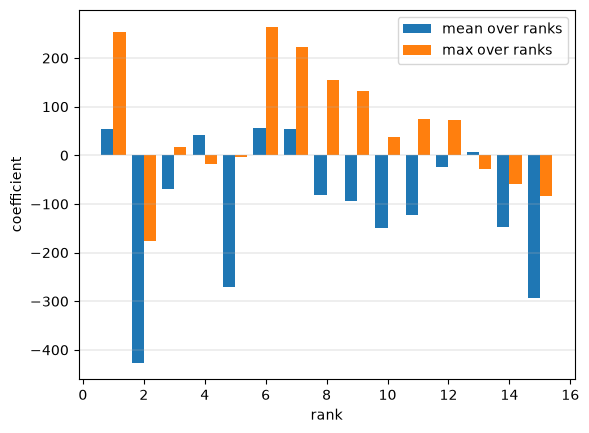

In [6]:
import matplotlib.pyplot as plt

# The by-hand steps and the pipeline are the same computation, not a resemblance.
assert np.allclose(detector[:-1].transform(responses), features, equal_nan=True)

mean_weights, max_weights = detector[-1].coef_[0].reshape(2, K)
ranks = np.arange(1, K + 1)

axes = plt.subplot()
axes.bar(ranks - 0.2, mean_weights, width=0.4, label="mean over ranks")
axes.bar(ranks + 0.2, max_weights, width=0.4, label="max over ranks")
axes.set(xlabel="rank", ylabel="coefficient")
axes.legend()
# Returns None, so the figure is the cell's only output -- an object repr above it is noise.
axes.grid(axis="y", linewidth=0.3)

## It composes with scikit-learn

Every `sklearn.model_selection` tool works on it.

Five folds over all 98 responses report a spread as well as a mean; the 25-answer holdout
above lands below every one of the five.

`LearningCurveDisplay` answers the question that decides whether to label more: the
5-fold AUC at 20, 40, 60, 80 and 98 responses. A curve still climbing at the right edge
says more labels are worth buying; one that has flattened says the next hundred buy nothing.

Every step's parameters are searchable, `parser__k` included. The classifier is refitted at
each width, so the comparison is legitimate — and the score climbing with `k` says the
signal here lives in the deeper ranks, not just the top one.


In [7]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_score

folds = StratifiedKFold(5, shuffle=True, random_state=SEED)

auc = cross_val_score(wepr(k=K), responses, y, cv=folds, scoring="roc_auc")
print(f"5-fold ROC-AUC: {auc.mean():.2f} +/- {auc.std():.2f}   {np.round(auc, 2)}")

search = GridSearchCV(wepr(), {"parser__k": [5, 10, 15]}, cv=folds, scoring="roc_auc")
search.fit(responses, y)
for k, mean in zip(search.cv_results_["param_parser__k"], search.cv_results_["mean_test_score"], strict=True):
    print(f"  k={k:>2}: {mean:.2f}")
search.best_estimator_

5-fold ROC-AUC: 0.93 +/- 0.03   [0.96 0.91 0.96 0.92 0.88]
  k= 5: 0.82
  k=10: 0.85
  k=15: 0.93


,steps,"[('parser', ...), ('entropy', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
Name,Type,Value
classes_,"ndarray[int64](2,)","[0,1]"
,k,15
,reduction,'wepr'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",inf
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'


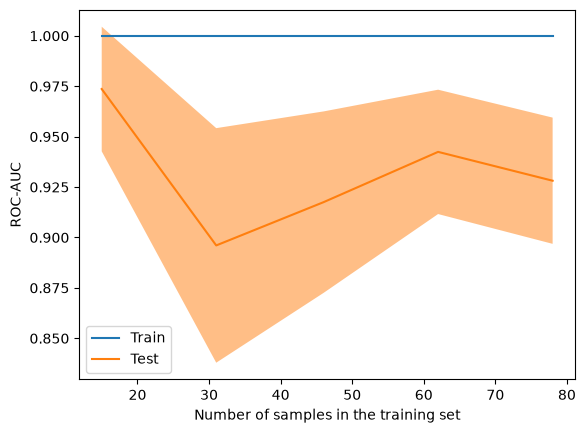

In [8]:
from sklearn.model_selection import LearningCurveDisplay

learning_curve = LearningCurveDisplay.from_estimator(
    wepr(k=K),
    responses,
    y,
    cv=folds,
    scoring="roc_auc",
    train_sizes=np.linspace(0.2, 1.0, 5),
    score_name="ROC-AUC",
    std_display_style="fill_between",
)

## Choosing the final estimator

`classifier=` takes any scikit-learn estimator. The default is the unregularised logistic
regression the shipped detectors were fitted with, and on data this separable it saturates: almost every score
lands on 0 or 1, which leaves a precision-recall curve with almost no points on it and no
threshold to choose between.

Regularising is one keyword, and it spreads the scores back out — same features, same split,
a curve you can actually pick an operating point from. `PrecisionRecallDisplay` draws both on
one axes, where the saturation is the shape of the curve rather than a count of thresholds.

Then pick the threshold with `TunedThresholdClassifierCV` rather than by reading a number
off the curve: it cross-validates the cut on the training set alone, so the operating point
is not chosen on the rows it is then reported against. It wraps the detector, so
`predict` uses the tuned cut while `predict_proba` still returns the detector's own scores.
The threshold is a number, not part of the `.skops` weights — it travels with the detector,
not inside it.


C=inf (default): AUC 0.84, 96% of scores at the rails, 16 distinct thresholds
          C=1.0: AUC 0.95, 0% of scores at the rails, 25 distinct thresholds


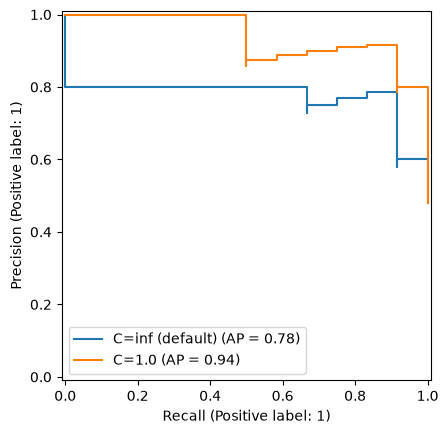

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import PrecisionRecallDisplay, precision_recall_curve

curves = None
for label, estimator in (("C=inf (default)", None), ("C=1.0", LogisticRegression(C=1.0, max_iter=1000))):
    fitted = wepr(k=K, classifier=estimator).fit(x_train, y_train)
    probabilities = fitted.predict_proba(x_test)[:, 1]
    decided = np.mean((probabilities < 0.01) | (probabilities > 0.99))
    thresholds = precision_recall_curve(y_test, probabilities)[2]
    print(
        f"{label:>15}: AUC {roc_auc_score(y_test, probabilities):.2f}, "
        f"{decided:.0%} of scores at the rails, {len(thresholds)} distinct thresholds"
    )
    # The first call makes the axes, the second draws onto it: `curves.ax_` is how a
    # Display hands its axes to the next one, with no figure to manage by hand.
    curves = PrecisionRecallDisplay.from_predictions(
        y_test, probabilities, name=label, ax=None if curves is None else curves.ax_
    )

In [10]:
from sklearn.model_selection import TunedThresholdClassifierCV

# Tuned on the training rows only, by cross-validation, and reported on the held-out ones.
tuned = TunedThresholdClassifierCV(
    wepr(k=K, classifier=LogisticRegression(C=1.0, max_iter=1000)),
    scoring="f1",
    cv=folds,
).fit(x_train, y_train)

print(f"threshold {tuned.best_threshold_:.2f} rather than 0.5, {tuned.best_score_:.2f} F1 in cross-validation")
print(classification_report(y_test, tuned.predict(x_test), target_names=["grounded", "hallucination"], zero_division=0))

threshold 0.47 rather than 0.5, 0.91 F1 in cross-validation
               precision    recall  f1-score   support

     grounded       1.00      0.77      0.87        13
hallucination       0.80      1.00      0.89        12

     accuracy                           0.88        25
    macro avg       0.90      0.88      0.88        25
 weighted avg       0.90      0.88      0.88        25



## Per-token scores

`predict_token_proba` scores every token position instead of pooling the response into one
number, which locates *where* a response drifts. Padded positions stay NaN rather than being
scored as real tokens.

These sample responses are one or two tokens long, so there is little to see.


In [11]:
per_token = detector.predict_token_proba(x_test[:3])  # (responses, tokens, 1)

for row, scores_per_token in zip(x_test[:3], per_token, strict=True):
    tokens = [t["token"] for t in row.completion["choices"][0]["logprobs"]["content"]]
    scored = " ".join(f"{token.strip()}={score:.2f}" for token, (score,) in zip(tokens, scores_per_token, strict=False))
    print(f"P={detector.predict_proba(row)[0, 1]:.2f}  {scored}")

P=1.00  Saturn=1.00
P=1.00  Colombia=1.00
P=1.00  David=1.00 Ricardo=1.00


## Save it, and load it back

`.skops` rather than a pickle. `from_pretrained` takes a `.skops` file, a directory holding
`model.skops`, or **a Hugging Face repository id** — the shipped detectors are loaded that
way, and yours is too once you push its `model.skops` to a repository of your own.

`k` is part of the weights, not a runtime option: the coefficients were fitted at one rank
count and mean nothing at another, so loading at a different `k` raises rather than
mis-shaping the score.

The rows scored below are held-out ones.

In [12]:
path = detector.save_estimator("wepr-trained.skops")
reloaded = BaseDetector.from_pretrained(path, "wepr", k=K)
print(f"{path}, reloaded at k={K}")

# Held-out answers: the rows the fit never saw.
for row, label in list(zip(x_test, y_test, strict=True))[:5]:
    said = (read_message(row.completion) or "").strip()
    print(f"[{'hallucination' if label else 'grounded    '}] P={reloaded.predict_proba(row)[0, 1]:.3f}  {said[:40]!r}")

# The rank count is part of the weights, so a mismatch is refused rather than mis-shaped.
try:
    BaseDetector.from_pretrained(path, "wepr", k=K - 1)
except ValueError as error:
    print(f"\nfrom_pretrained(path, 'wepr', k={K - 1}) -> ValueError: {error}")

wepr-trained.skops, reloaded at k=15
[hallucination] P=1.000  'Saturn'
[hallucination] P=1.000  'Colombia'
[hallucination] P=1.000  'David Ricardo'
[grounded    ] P=1.000  'Ottawa'
[grounded    ] P=0.000  'Beethoven'

from_pretrained(path, 'wepr', k=14) -> ValueError: The wepr detector at 'wepr-trained.skops' takes 30 feature(s), but k=14 needs 28. Its coefficients are fixed at the rank count they were trained at; pass k=15, or use a detector trained at k=14.


## Where to go next

- `epr` is the same call with one word changed: it pools every rank into a single feature
  instead of `2k`, which is the one to reach for when there is too little labelled data to
  fit `wepr`'s coefficients. `EntropyTransformer(reduction=...)` also takes a callable
  `(s_kj, axis) -> features`, so the two named reductions are not the only ones.
- `scripts/train_detector.py` reads these same two files and reports bootstrap confidence
  intervals around the AUC, which a holdout this size needs.
- `predict_proba` and `predict_token_proba` are the whole scoring surface; a fitted detector
  is an ordinary estimator from here on.
